# Manning's n Region Polygon Authoring

This workflow writes Manning's n calibration region polygons to the plain-text HEC-RAS geometry file with `GeomLandCover.set_mannings_region_polygons()` and checks the paired regional Manning's n table remains readable.

In [1]:
from pathlib import Path
import logging
import shutil
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == "examples"
    else Path.cwd().resolve()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
logging.getLogger("numexpr").setLevel(logging.WARNING)
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)

from ras_commander.RasExamples import RasExamples
from ras_commander.geom.GeomLandCover import GeomLandCover
from ras_commander.hdf.HdfLandCover import HdfLandCover
from ras_commander.hdf.HdfMesh import HdfMesh

logging.getLogger("ras_commander").setLevel(logging.WARNING)

work_dir = Path("working") / "219_mannings_region_polygon_authoring"
work_dir.mkdir(parents=True, exist_ok=True)

project_path = RasExamples.extract_project(
    "Muncie",
    output_path=work_dir,
    suffix="219_region_polygons",
)

source_geom = project_path / "Muncie.g04"
authoring_geom = project_path / "Muncie_region_polygon_authoring.g04"
shutil.copy2(source_geom, authoring_geom)

source_geom_hdf = project_path / "Muncie.g04.hdf"
regions = HdfLandCover.get_mannings_region_polygons(source_geom_hdf)
mesh_areas = HdfMesh.get_mesh_areas(source_geom_hdf)
flat_area = regions[regions["Name"].astype(str).str.strip() == "Flat Area"].copy()

assert len(flat_area) == 1, "Expected one Muncie 'Flat Area' calibration region"
assert not mesh_areas.empty, "Expected Muncie 2D flow area perimeter"
flat_area[["Name", "geometry"]]


,Name,geometry
0,Flat Area,"POLYGON ((407719.543 1803114.117, 407651.697 1..."


In [2]:
GeomLandCover.set_mannings_region_polygons(
    authoring_geom,
    flat_area[["Name", "geometry"]],
)

region_n = GeomLandCover.get_region_mannings_n(authoring_geom)
flat_area_n = region_n[region_n["Region Name"] == "Flat Area"].reset_index(drop=True)

assert not flat_area_n.empty, "Region n-value table was not preserved"
assert authoring_geom.with_suffix(".g04.bak").exists(), "Expected a geometry backup"

flat_area_n


,Table Number,Land Cover Name,MainChannel,Region Name
0,6,building,100.000,Flat Area
1,6,medium density residential,0.072,Flat Area
2,6,open space,0.036,Flat Area
3,6,park,0.054,Flat Area
4,6,trees,0.108,Flat Area
5,6,urban,0.090,Flat Area


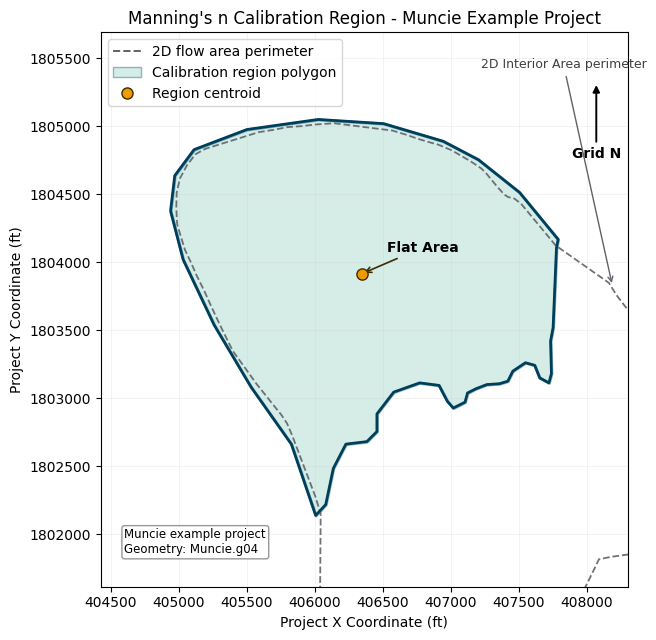

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))

mesh_areas.boundary.plot(
    ax=ax,
    color="#5f6368",
    linewidth=1.3,
    linestyle="--",
    alpha=0.9,
)

flat_area.plot(
    ax=ax,
    facecolor="#9bd3c6",
    edgecolor="#005f73",
    linewidth=2.2,
    alpha=0.42,
)
flat_area.boundary.plot(ax=ax, color="#003f5c", linewidth=2.0)

centroid = flat_area.geometry.iloc[0].centroid
ax.scatter(
    [centroid.x],
    [centroid.y],
    color="#ee9b00",
    edgecolor="#3d2c00",
    s=65,
    zorder=5,
    label="Region centroid",
)
ax.annotate(
    "Flat Area",
    xy=(centroid.x, centroid.y),
    xytext=(18, 16),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": "#3d2c00", "lw": 1.2},
)
ax.annotate(
    "Grid N",
    xy=(0.94, 0.91),
    xytext=(0.94, 0.78),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.4},
)

legend_handles = [
    Line2D(
        [0],
        [0],
        color="#5f6368",
        linestyle="--",
        linewidth=1.4,
        label="2D flow area perimeter",
    ),
    Patch(
        facecolor="#9bd3c6",
        edgecolor="#005f73",
        alpha=0.42,
        label="Calibration region polygon",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#ee9b00",
        markeredgecolor="#3d2c00",
        markersize=8,
        label="Region centroid",
    ),
]

ax.text(
    0.045,
    0.055,
    "Muncie example project\nGeometry: Muncie.g04",
    transform=ax.transAxes,
    fontsize=8.5,
    va="bottom",
    bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "#8a8a8a", "alpha": 0.88},
)

mesh_bounds = mesh_areas.total_bounds
region_bounds = flat_area.total_bounds
x_span = region_bounds[2] - region_bounds[0]
y_span = region_bounds[3] - region_bounds[1]
ax.annotate(
    "2D Interior Area perimeter",
    xy=(region_bounds[2] + 0.14 * x_span, region_bounds[3] - 0.42 * y_span),
    xytext=(region_bounds[2] - 0.20 * x_span, region_bounds[3] + 0.13 * y_span),
    fontsize=9,
    color="#3c4043",
    arrowprops={"arrowstyle": "->", "color": "#5f6368", "lw": 1.0},
)

ax.set_xlim(region_bounds[0] - 0.18 * x_span, region_bounds[2] + 0.18 * x_span)
ax.set_ylim(region_bounds[1] - 0.18 * y_span, region_bounds[3] + 0.22 * y_span)

ax.set_title("Manning's n Calibration Region - Muncie Example Project")
ax.set_xlabel("Project X Coordinate (ft)")
ax.set_ylabel("Project Y Coordinate (ft)")
ax.set_aspect("equal", adjustable="box")
ax.ticklabel_format(style="plain", useOffset=False)
ax.grid(True, color="#c9c9c9", linewidth=0.45, alpha=0.35)
ax.legend(handles=legend_handles, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()
